In [1]:
import numpy as np

data_path = r"..\data\NeRF\tiny_nerf_data.npz"
data = np.load(data_path)

print(data)


NpzFile '..\\data\\NeRF\\tiny_nerf_data.npz' with keys: images, poses, focal


## 输入
- 注意：NeRF里面都是以像素为单位
- pose：相机位置姿态矩阵：相机空间->世界空间(C2W)
- focal：焦距（像素单位）
- 成像高度和宽度就是image的宽高

In [2]:
images = data["images"]  # 图像
poses = data["poses"]  # 相机位姿
focal = data["focal"]  # 相机焦距
images.shape, poses.shape, focal

((106, 100, 100, 3), (106, 4, 4), array(138.8888789))

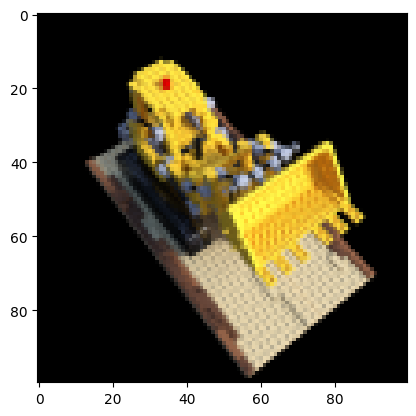

In [3]:
import matplotlib.pyplot as plt

plt.imshow(images[3])  # 图片

## 数据处理

## 批次数据

In [ ]:
import torch

# 转 tensor，注意 dtype：numpy 默认 float64，要显式转成 float32 以匹配 nn.Linear
poses = torch.from_numpy(poses).float()
images = torch.from_numpy(images).float()
focal = float(focal)  # 标量直接用 Python float

N = images.shape[0]
H = images.shape[1]
W = images.shape[2]
NUM_PIXELS = H * W

batch_size = 1024
point_size = 64  # 沿每条 ray 采样的点数

# tiny_nerf 标准取值（场景空间单位，不是像素）
NEAR = 2.0
FAR = 6.0


def gen_batch():
    """
    每次随机选一张图，从中采样 batch_size 个像素，得到对应的 ray。

    返回：
        rays_o:     [B, 3]  ray 原点（世界坐标，本图所有 ray 共享相机中心）
        rays_d:     [B, 3]  ray 方向（世界坐标，已用 pose 旋转）
        target_rgb: [B, 3]  对应像素的真实颜色，作为训练目标
    """
    img_i = torch.randint(0, high=N, (1,)).item()
    target = images[img_i]  # [H, W, 3]
    pose = poses[img_i]  # [4, 4]

    # 采样像素的一维索引，再换算回 (x, y)
    idx = torch.randperm(H * W)[:batch_size]
    x = idx % W
    y = idx // W
    target_rgb = target.reshape(-1, 3)[idx]  # [B, 3]

    # 相机空间下的方向向量（针孔模型）
    # 注意：图像 y 朝下，相机 y 朝上，所以 vy 取负
    dirs = torch.stack(
        [
            (x - W / 2) / focal,
            -(y - H / 2) / focal,
            -torch.ones_like(x, dtype=torch.float32),
        ],
        dim=-1,
    )  # [B, 3]

    # 旋转到世界空间。pose 是 C2W、列向量约定，
    # 行向量代码必须乘 R.T
    rays_d = dirs @ pose[:3, :3].T  # [B, 3]
    # 同一张图的所有 ray 共享相机原点
    rays_o = pose[:3, 3].expand_as(rays_d)  # [B, 3]
    return rays_o, rays_d, target_rgb


## 样点

In [5]:
def sample_points(rays_o, rays_d, n_samples=point_size, perturb=True):
    """
    沿每条 ray 在 [NEAR, FAR] 区间采样 n_samples 个 3D 点。

    参数：
        rays_o: [B, 3]  ray 原点
        rays_d: [B, 3]  ray 方向（不要求单位长度）
        perturb: 是否做分层抖动（训练时 True，渲染时 False）

    返回：
        pts:    [B, S, 3]  3D 采样点，送入 MLP
        z_vals: [B, S]     每个采样点对应的 t 值（沿 ray 的距离），
                           体渲染计算 alpha 时需要
    """
    B = rays_o.shape[0]

    # 在 [0, 1] 上等间距取 S 个点，再线性映射到 [NEAR, FAR]
    t_vals = torch.linspace(0.0, 1.0, n_samples)  # [S]
    z_vals = NEAR + (FAR - NEAR) * t_vals  # [S]
    z_vals = z_vals.expand(B, n_samples)  # [B, S]

    if perturb:
        # 分层采样（stratified sampling）：把 [NEAR, FAR] 分成 S 段，
        # 在每段内部均匀抖动一个点，避免每条 ray 都采到固定 z 值
        mids = 0.5 * (z_vals[..., 1:] + z_vals[..., :-1])
        upper = torch.cat([mids, z_vals[..., -1:]], dim=-1)
        lower = torch.cat([z_vals[..., :1], mids], dim=-1)
        z_vals = lower + (upper - lower) * torch.rand_like(z_vals)

    # 由 ray 方程 p(t) = o + t * d 算出 3D 点
    pts = rays_o[:, None, :] + rays_d[:, None, :] * z_vals[..., None]  # [B, S, 3]
    return pts, z_vals


# 简单自检：跑一遍看看 shape 和数值是否合理
rays_o, rays_d, target_rgb = gen_batch()
pts, z_vals = sample_points(rays_o, rays_d)
print(f"rays_o:     {rays_o.shape}")
print(f"rays_d:     {rays_d.shape}")
print(f"target_rgb: {target_rgb.shape}")
print(f"pts:        {pts.shape}")
print(f"z_vals:     {z_vals.shape}, range=[{z_vals.min():.2f}, {z_vals.max():.2f}]")

rays_o:     torch.Size([1024, 3])
rays_d:     torch.Size([1024, 3])
target_rgb: torch.Size([1024, 3])
pts:        torch.Size([1024, 64, 3])
z_vals:     torch.Size([1024, 64]), range=[2.00, 6.00]


## 位置编码
把 3D 坐标先映射到高频 sin/cos 基底，再喂给 MLP，否则网络学不出图像里的高频细节。

In [6]:
# ============================================================================
# 位置编码 (Positional Encoding)
# ============================================================================
# 论文公式 (Sec. 5.1):
#   γ(p) = ( p,
#            sin(2^0 · π · p), cos(2^0 · π · p),
#            sin(2^1 · π · p), cos(2^1 · π · p),
#            ...,
#            sin(2^(L-1) · π · p), cos(2^(L-1) · π · p) )
#
# 为什么需要它?
#   ReLU MLP 有 "spectral bias" —— 天生倾向于拟合低频信号，直接喂
#   原始 (x, y, z) 学不出图像中的高频细节 (锯齿边缘、纹理)。位置编码
#   把坐标投影到一组指数增长频率的 sin/cos 上，相当于给网络铺好了
#   一个"高频字典"。
# ============================================================================

L_POS = 6  # 频率个数 L
#   - L 越大可表达的频率越高，细节越丰富
#   - 但 L 太大会过拟合 + 训练不稳
#   - 原 NeRF: 位置 L=10, 方向 L=4
#   - tiny NeRF: L=6 已够看
POS_DIM = 3 * (1 + 2 * L_POS)  # 编码后维度
#   原始 3 + 每个频率 (sin, cos) × 3 坐标 × L
#   L=6 时 = 3 × (1 + 12) = 39


def positional_encoding(x, L=L_POS):
    """
    对每个坐标分量做多频段 sin/cos 编码。

    Parameters
    ----------
    x : torch.Tensor, shape [..., 3]
        输入的 3D 点坐标。任意 batch 维度都可以，但最后一维必须是 3。
        建议数值大致在 [-1, 1] ~ [-π, π] 之间，否则最高频项 (2^(L-1) · π · x)
        会进入剧烈震荡区，梯度不稳。tiny_nerf 场景大致在 [-2, 2] OK。
    L : int, 默认 L_POS
        使用的频率个数。频率序列是 2^0, 2^1, ..., 2^(L-1)，对应波长
        从 2 逐倍缩短到 2 / 2^(L-1)。

    Returns
    -------
    torch.Tensor, shape [..., 3 * (1 + 2L)]
        编码后的特征向量。
        按 [原始 x, sin 系列, cos 系列] 的顺序 concat。
    """
    out = [x]
    # 频率序列: 2^0·π, 2^1·π, ..., 2^(L-1)·π
    freqs = (2.0 ** torch.arange(L, dtype=x.dtype, device=x.device)) * torch.pi  # [L]
    # 把 x 广播到 [..., 3, L]，每个坐标分量乘上每个频率
    xb = x[..., None] * freqs  # [..., 3, L]
    # sin / cos 各自展平到 [..., 3*L]
    out.append(torch.sin(xb).reshape(*x.shape[:-1], -1))
    out.append(torch.cos(xb).reshape(*x.shape[:-1], -1))
    return torch.cat(out, dim=-1)


# --- 自检 ---
_enc = positional_encoding(torch.randn(5, 3))
print(f"L = {L_POS}, POS_DIM = {POS_DIM}, encoded shape = {tuple(_enc.shape)}")

L = 6, POS_DIM = 39, encoded shape = (5, 39)


## NeRF 模型
一个简单的 8 层全连接 MLP：输入是位置编码后的 3D 坐标，输出 `(r, g, b, sigma)`。
tiny NeRF 不区分视角方向（论文里 rgb 还会依赖于 view direction），所以网络只有一支头。
第 4 层做一次跳跃连接，把原始位置编码再 concat 一遍。

In [7]:
import torch.nn as nn


class NeRF(nn.Module):
    """
    tiny NeRF MLP 网络

    结构 (默认 D=8, W=256, input_dim=39, skip=4):
        input (39)
          ├─ Linear(39  -> 256) + ReLU              # layer 0
          ├─ Linear(256 -> 256) + ReLU              # layer 1
          ├─ Linear(256 -> 256) + ReLU              # layer 2
          ├─ Linear(256 -> 256) + ReLU              # layer 3
          ├─ concat (h, x) -> 256 + 39 = 295        # ← skip connection 在第 4 层入口
          ├─ Linear(295 -> 256) + ReLU              # layer 4
          ├─ Linear(256 -> 256) + ReLU              # layer 5
          ├─ Linear(256 -> 256) + ReLU              # layer 6
          ├─ Linear(256 -> 256) + ReLU              # layer 7
          └─ Linear(256 -> 4)                       # 输出 head: 3 rgb + 1 sigma

    与原版 NeRF 的差异:
        原 NeRF 在最后一层之后再 concat 编码后的 view direction，并多一支
        rgb 分支，从而能学到镜面反射、视角依赖的高光。tiny 版本砍掉了视角，
        只能学漫反射，但对静态对象足够。
    """

    def __init__(self, D=8, W=256, input_dim=POS_DIM, skip=4):
        """
        Parameters
        ----------
        D : int, 默认 8
            主干 MLP 的层数 (不含输出 head)。原 NeRF 用 8。
        W : int, 默认 256
            每个隐藏层的宽度 (通道数)。原 NeRF 用 256。
        input_dim : int, 默认 POS_DIM
            输入维度 = 位置编码后的维度。
        skip : int, 默认 4
            在第 skip 层的输入处再 concat 一遍原始输入 x，
            用来对抗深层网络中的梯度衰减、保留高频信号。
            论文里取 4 (网络中点)。
        """
        super().__init__()
        self.D, self.W, self.skip = D, W, skip

        self.layers = nn.ModuleList()
        for i in range(D):
            if i == 0:
                in_dim = input_dim  # 第一层吃位置编码
            elif i == skip:
                in_dim = W + input_dim  # skip 层多吃一份原始输入
            else:
                in_dim = W
            self.layers.append(nn.Linear(in_dim, W))

        # 输出 head: 前 3 维 rgb logits  -> sigmoid -> [0, 1]
        #          第 4 维 sigma logits -> ReLU    -> [0, ∞)
        # 激活放到 volume_render 里做，本类只输出原始 logits
        self.out_head = nn.Linear(W, 4)

    def forward(self, x):
        """
        Parameters
        ----------
        x : torch.Tensor, shape [N, input_dim]
            位置编码后的 batch 点。
            N 通常 = batch_size × point_size (训练) 或 chunk × point_size (渲染)。

        Returns
        -------
        torch.Tensor, shape [N, 4]
            未激活的原始输出 (rgb_logits, sigma_logits)。
        """
        h = x
        for i, layer in enumerate(self.layers):
            if i == self.skip:
                h = torch.cat([h, x], dim=-1)  # skip connection
            h = torch.relu(layer(h))
        return self.out_head(h)


# --- 自检 ---
_model = NeRF()
_test = torch.randn(8, POS_DIM)
print("model output shape:", _model(_test).shape)
print("num params:", sum(p.numel() for p in _model.parameters()))

model output shape: torch.Size([8, 4])
num params: 481796


## 体渲染
把 MLP 在每个采样点输出的 (rgb, sigma) 用体渲染积分公式合成成一条 ray 的颜色。
- `alpha_i = 1 - exp(-sigma_i * delta_i)`：采样点 i 的不透明度
- `T_i = ∏_{j<i}(1 - alpha_j)`：到达该点前的累计透射率
- `C = Σ_i T_i * alpha_i * c_i`：最终颜色

In [8]:
def volume_render(raw, z_vals, rays_d, white_bg=True):
    """
    把 MLP 在 ray 上各采样点的 (rgb, sigma) 用体渲染合成成 ray 最终颜色。

    论文体渲染公式 (式 3):
        C(r) = Σ_i T_i · (1 - exp(-σ_i · δ_i)) · c_i
        T_i  = exp( -Σ_{j<i} σ_j · δ_j ) = ∏_{j<i} (1 - α_j)
        α_i  = 1 - exp(-σ_i · δ_i)
        w_i  = T_i · α_i                    # 第 i 个点对最终颜色的贡献权重

    其中 δ_i 是相邻采样点的"真实欧式距离"(不是 t 间距)。

    Parameters
    ----------
    raw : torch.Tensor, shape [B, S, 4]
        MLP 的原始输出 (未激活)。
            - raw[..., 0:3] 是 RGB logits，激活后 = sigmoid -> [0, 1]
            - raw[..., 3]   是 sigma logits，激活后 = ReLU -> [0, ∞)
        B = 一批 ray 的数量，S = 每条 ray 的采样点数。
    z_vals : torch.Tensor, shape [B, S]
        每个采样点沿 ray 的 t 值 (距离参数)。
        由 sample_points 返回，单调递增。
    rays_d : torch.Tensor, shape [B, 3]
        每条 ray 的方向向量 (世界坐标)。**不要预先归一化**：
        这里要用 |d| 把 t 间距换算成真实欧式距离。
    white_bg : bool, 默认 True
        是否按白色背景合成 `(1 - acc) · white`。
        本项目实测在 tiny_nerf (黑底) 数据集上必须开 True，否则训练会发散
        / 收敛到全黑！原因是：
            ① 黑底数据集下，"sigma 全 0"也能让 BG 像素满足 rgb_map=0=GT，
              所以网络很容易陷在 sigma=0 的平凡解里，永远学不出物体。
            ② 加上 (1 - acc) · 1 后，BG 像素的预测变成 1，与 GT(=0) 差距很大，
              产生强梯度逼网络把 sigma 拉起来 (使 acc→1)；同时网络会把"无穷远那
              个采样点"的 rgb 学成 0 (黑) 以消掉多出来的白。
            ③ 训练完后 acc≈1, (1-acc)·white≈0，对最终颜色几乎没贡献，但
              它在训练早期提供的"密度正则"是无法替代的。
        对白底数据集 (例如 NeRF-Synthetic 的 lego/chair) 则是物理正确选择。
        如果你的数据集背景颜色不是黑也不是白，请改写这一项。

    Returns
    -------
    rgb_map : torch.Tensor, shape [B, 3]
        合成后的 ray 颜色，是训练时的预测值。
    depth_map : torch.Tensor, shape [B]
        权重加权后的期望 t 值，可视为深度估计。
    acc_map : torch.Tensor, shape [B]
        ray 上累计不透明度 ∈ [0, 1]。1 = 完全吸收, 0 = 完全穿过。
    weights : torch.Tensor, shape [B, S]
        每个采样点的贡献权重 w_i。做 hierarchical sampling 时会用到。
    """
    # ------------------------------------------------------------------
    # 1) 把网络原始输出激活成可解释的物理量
    # ------------------------------------------------------------------
    rgb = torch.sigmoid(raw[..., :3])  # [B, S, 3]  颜色 ∈ [0, 1]
    sigma = torch.relu(raw[..., 3])  # [B, S]     密度 ≥ 0

    # ------------------------------------------------------------------
    # 2) 计算相邻采样点的 t 间距 δ
    #    最后一段补 1e10 表示"延伸到无穷远"
    #      => 若 σ_last > 0 则 α_last ≈ 1 (最后一定吸光)
    #      网络通过这个采样点直接学到"无穷远的颜色"，相当于隐式的背景。
    # ------------------------------------------------------------------
    dists = z_vals[..., 1:] - z_vals[..., :-1]  # [B, S-1]
    dists = torch.cat([dists, torch.full_like(dists[..., :1], 1e10)], dim=-1)  # [B, S]
    # rays_d 不是单位向量，dists 只是 t 间距，乘 |d| 才是真实距离
    dists = dists * torch.norm(rays_d[..., None, :], dim=-1)  # [B, S]

    # ------------------------------------------------------------------
    # 3) 每个采样点的不透明度 α_i = 1 - exp(-σ_i · δ_i)
    # ------------------------------------------------------------------
    alpha = 1.0 - torch.exp(-sigma * dists)  # [B, S]

    # ------------------------------------------------------------------
    # 4) 透射率 T_i = ∏_{j<i} (1 - α_j)，前缀积
    #    在最前面 pad 1，使得 T_0 = 1 (出发还没被吸收)
    #    1e-10 防止 log(0) 之类的数值问题
    # ------------------------------------------------------------------
    ones = torch.ones_like(alpha[..., :1])
    trans = torch.cumprod(torch.cat([ones, 1.0 - alpha + 1e-10], dim=-1), dim=-1)[
        ..., :-1
    ]  # [B, S]
    weights = alpha * trans  # [B, S]

    # ------------------------------------------------------------------
    # 5) 合成颜色 / 深度 / 累计不透明度
    # ------------------------------------------------------------------
    rgb_map = (weights[..., None] * rgb).sum(dim=-2)  # [B, 3]
    depth_map = (weights * z_vals).sum(dim=-1)  # [B]
    acc_map = weights.sum(dim=-1)  # [B]

    # ------------------------------------------------------------------
    # 6) 白色背景合成 (★ 关键 —— 见参数说明)
    # ------------------------------------------------------------------
    if white_bg:
        rgb_map = rgb_map + (1.0 - acc_map[..., None])

    return rgb_map, depth_map, acc_map, weights

## 训练
- 损失：渲染 rgb 与真实像素颜色的 MSE
- 指标：PSNR = -10·log10(MSE)，越大越好
- 优化器：Adam, lr=5e-4

每个 iter 流程：
1. 随机选一张图、采 batch_size 条 ray，拿到 GT 颜色
2. 沿 ray 取 S 个 3D 点
3. 位置编码后送 MLP，得到逐点 rgb/sigma
4. 体渲染合成 ray 颜色
5. 与 GT MSE 反传

In [9]:
import time

# ----------------------------------------------------------------------------
# 训练超参
# ----------------------------------------------------------------------------
num_iters = 1000  # 总 iter 数
#   - 2000 iter 在 GPU 上 ~1-3 min, PSNR 大约 22-25 dB
#   - 推到 10000+ 可上 27-28 dB，更清晰
log_every = 100  # 每多少 iter 打印一次日志
lr = 5e-4  # Adam 学习率，跟原 NeRF 一致

# ----------------------------------------------------------------------------
# 设备 & 模型
# ----------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

torch.manual_seed(0)  # 复现性
model = NeRF(input_dim=POS_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

losses, psnrs = [], []

t0 = time.time()
for it in range(num_iters):
    # ------------------------------------------------------------------
    # 1) 采一批 ray + 对应 GT 颜色 (CPU, 由 gen_batch 完成)
    #    rays_o     [B, 3]   ray 起点 (世界坐标)
    #    rays_d     [B, 3]   ray 方向 (世界坐标，未单位化)
    #    target_rgb [B, 3]   该像素的 GT 颜色
    # ------------------------------------------------------------------
    rays_o, rays_d, target_rgb = gen_batch()

    # ------------------------------------------------------------------
    # 2) 沿 ray 采样 3D 点 (CPU)
    #    pts    [B, S, 3]   3D 采样点
    #    z_vals [B, S]      每个采样点的 t 值
    # ------------------------------------------------------------------
    pts, z_vals = sample_points(rays_o, rays_d, perturb=True)

    # ------------------------------------------------------------------
    # 3) 搬到 device
    #    images / poses 留在 CPU，避免改动 gen_batch
    # ------------------------------------------------------------------
    rays_d = rays_d.to(device)
    target_rgb = target_rgb.to(device)
    pts = pts.to(device)
    z_vals = z_vals.to(device)

    # ------------------------------------------------------------------
    # 4) 位置编码 + MLP 前向
    #    pts_flat [B*S, 3]        把 batch 和采样维度合并成一个大 batch
    #    pts_enc  [B*S, POS_DIM]  编码后的输入
    #    raw      [B,   S, 4]     reshape 回 ray 级，方便后面体渲染
    # ------------------------------------------------------------------
    pts_flat = pts.reshape(-1, 3)
    pts_enc = positional_encoding(pts_flat, L=L_POS)
    raw = model(pts_enc).reshape(*pts.shape[:-1], 4)

    # ------------------------------------------------------------------
    # 5) 体渲染合成 ray 颜色
    #    ★ white_bg=True 必须打开，否则在 tiny_nerf (黑底) 上训练会发散
    #      或收敛到全黑 (网络陷入 sigma=0 的平凡解)。详见 volume_render docstring。
    # ------------------------------------------------------------------
    rgb_map, depth_map, acc_map, weights = volume_render(raw, z_vals, rays_d, white_bg=True)

    # ------------------------------------------------------------------
    # 6) MSE loss + PSNR 监控
    #    PSNR = -10 · log10(MSE), 越大越好。
    #    常见基准: 20 = 能看出形状, 25 = 较清晰, 30+ = 接近原图。
    # ------------------------------------------------------------------
    loss = torch.mean((rgb_map - target_rgb) ** 2)
    psnr = -10.0 * torch.log10(loss.detach())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    psnrs.append(psnr.item())

    if it % log_every == 0 or it == num_iters - 1:
        dt = time.time() - t0
        print(
            f"iter {it:5d} | loss {loss.item():.4f} | psnr {psnr.item():5.2f} | elapsed {dt:6.1f}s"
        )

print("done.")

device: cuda
iter     0 | loss 0.4313 | psnr  3.65 | elapsed    0.4s
iter   100 | loss 0.1012 | psnr  9.95 | elapsed    5.7s
iter   200 | loss 0.0616 | psnr 12.10 | elapsed   11.1s
iter   300 | loss 0.0277 | psnr 15.58 | elapsed   16.1s
iter   400 | loss 0.0152 | psnr 18.18 | elapsed   21.0s
iter   500 | loss 0.0151 | psnr 18.21 | elapsed   26.0s
iter   600 | loss 0.0087 | psnr 20.60 | elapsed   30.8s
iter   700 | loss 0.0085 | psnr 20.71 | elapsed   35.8s
iter   800 | loss 0.0113 | psnr 19.46 | elapsed   40.8s
iter   900 | loss 0.0103 | psnr 19.87 | elapsed   46.0s
iter   999 | loss 0.0064 | psnr 21.91 | elapsed   50.8s
done.


## 渲染整张图像
训练时每张图只采了 batch_size 个像素。要看效果就得渲染所有 H×W 条 ray。
ray 总数 = H·W = 10 000，必须切块进网络，否则显存吃不消。

In [10]:
@torch.no_grad()
def render_image(pose, H_=H, W_=W, focal_=focal, chunk=4096, white_bg=True):
    """
    给定一个相机位姿，用当前 `model` 渲染出一整张图像。

    Parameters
    ----------
    pose : torch.Tensor, shape [4, 4]
        相机外参 (C2W, 相机坐标 -> 世界坐标)。与 gen_batch 中使用的格式一致。
        前 3×3 是旋转，第 4 列前 3 个分量是相机位置。
    H_ : int, 默认 H (数据集图像高度)
        要渲染的图像高度 (像素)。
    W_ : int, 默认 W (数据集图像宽度)
        要渲染的图像宽度 (像素)。
    focal_ : float, 默认 focal (数据集相机焦距)
        焦距 (像素单位)。
    chunk : int, 默认 4096
        每次送进 MLP 的 ray 数量。
        chunk × point_size 个采样点会同时前向，吃显存:
            chunk × S × W (隐藏宽度) 量级。
        100×100 一张图 = 10000 条 ray，chunk=4096 分 3 次完成。
        显存不够就调小。
    white_bg : bool, 默认 True
        必须和训练时的 volume_render 设置保持一致，否则渲染颜色不对。
        详细见 volume_render 文档。

    Returns
    -------
    rgb : torch.Tensor, shape [H_, W_, 3]
        渲染后的图像，数值 ∈ [0, 1]，CPU 张量。
    depth : torch.Tensor, shape [H_, W_]
        每个像素的期望深度 (t 值)，CPU 张量。
    """
    model.eval()

    # --------------------------------------------------------------
    # 1) 为整张图每个像素生成相机空间下的 ray 方向
    #    indexing="ij": 第一输出沿 axis-0 (行 j) 变化, 第二输出沿 axis-1 (列 i)
    # --------------------------------------------------------------
    j, i = torch.meshgrid(
        torch.arange(H_, dtype=torch.float32),
        torch.arange(W_, dtype=torch.float32),
        indexing="ij",
    )
    # 针孔相机：每个像素 (i, j) 对应一条方向向量
    # y 取负 —— 图像 y 朝下、相机 y 朝上
    dirs = torch.stack(
        [
            (i - W_ / 2) / focal_,
            -(j - H_ / 2) / focal_,
            -torch.ones_like(i),
        ],
        dim=-1,
    )  # [H_, W_, 3]

    # --------------------------------------------------------------
    # 2) 把方向转到世界坐标 (旋转矩阵的转置)
    # --------------------------------------------------------------
    pose_cpu = pose.cpu() if pose.is_cuda else pose
    rays_d = dirs @ pose_cpu[:3, :3].T  # [H_, W_, 3]
    rays_o = pose_cpu[:3, 3].expand_as(rays_d)  # [H_, W_, 3]  所有 ray 共享相机原点
    rays_o = rays_o.reshape(-1, 3)  # [H_*W_, 3]
    rays_d = rays_d.reshape(-1, 3)  # [H_*W_, 3]

    # --------------------------------------------------------------
    # 3) 分 chunk 渲染，避免 OOM
    # --------------------------------------------------------------
    rgb_chunks, depth_chunks = [], []
    for k in range(0, rays_o.shape[0], chunk):
        ro = rays_o[k : k + chunk]
        rd = rays_d[k : k + chunk]

        # 渲染时关闭 perturb，让结果稳定可复现
        pts, z_vals = sample_points(ro, rd, perturb=False)

        pts = pts.to(device)
        z_vals = z_vals.to(device)
        rd_dev = rd.to(device)

        pts_enc = positional_encoding(pts.reshape(-1, 3), L=L_POS)
        raw = model(pts_enc).reshape(*pts.shape[:-1], 4)

        rgb_map, depth_map, _, _ = volume_render(raw, z_vals, rd_dev, white_bg=white_bg)

        rgb_chunks.append(rgb_map.cpu())
        depth_chunks.append(depth_map.cpu())

    model.train()
    rgb = torch.cat(rgb_chunks, dim=0).reshape(H_, W_, 3).clamp(0, 1)
    depth = torch.cat(depth_chunks, dim=0).reshape(H_, W_)
    return rgb, depth

## 可视化训练效果
随便挑一张训练集里的相机位姿渲染一遍，跟原图对比。再看看 loss / PSNR 曲线。

test image #3: MSE=0.0081, PSNR=20.92


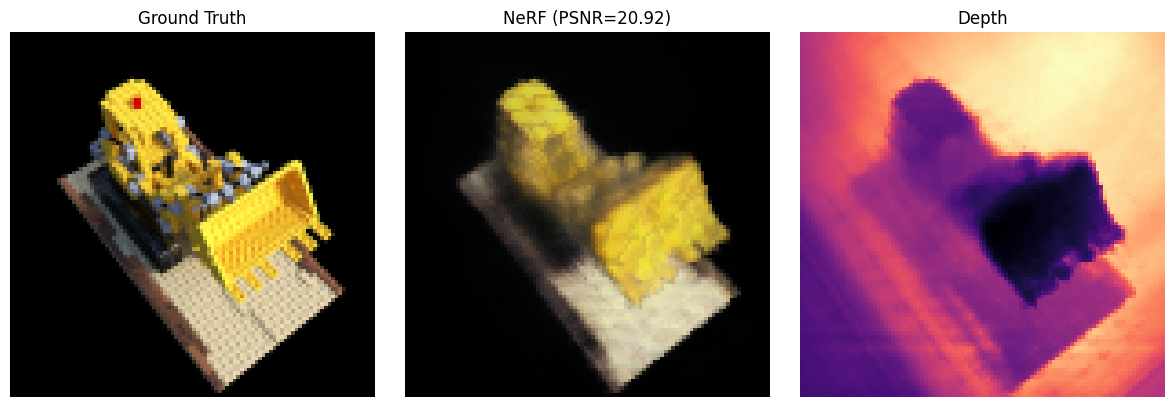

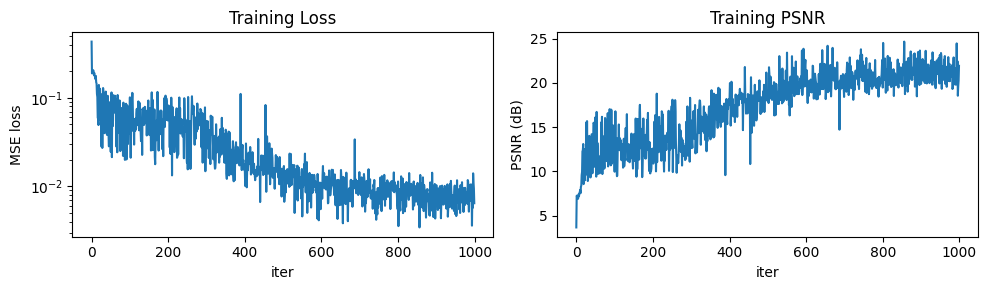

In [11]:
from typing import Any

import matplotlib.pyplot as plt
import numpy as np

# 1) 对比一张训练集图片的 GT 与 NeRF 渲染结果
test_idx = 3
test_pose = poses[test_idx]
gt: np.ndarray[tuple[Any, ...], np.dtype[Any]] = images[test_idx].cpu().numpy()

rgb_pred, depth_pred = render_image(test_pose)
rgb_np = rgb_pred.numpy()
depth_np = depth_pred.numpy()

test_mse = float(np.mean((rgb_np - gt) ** 2))
test_psnr = -10.0 * np.log10(max(test_mse, 1e-10))
print(f"test image #{test_idx}: MSE={test_mse:.4f}, PSNR={test_psnr:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gt)
axes[0].set_title("Ground Truth")
axes[0].axis("off")
axes[1].imshow(rgb_np)
axes[1].set_title(f"NeRF (PSNR={test_psnr:.2f})")
axes[1].axis("off")
axes[2].imshow(depth_np, cmap="magma")
axes[2].set_title("Depth")
axes[2].axis("off")
plt.tight_layout()
plt.show()

# 2) 训练曲线
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(losses)
axes[0].set_yscale("log")
axes[0].set_xlabel("iter")
axes[0].set_ylabel("MSE loss")
axes[0].set_title("Training Loss")
axes[1].plot(psnrs)
axes[1].set_xlabel("iter")
axes[1].set_ylabel("PSNR (dB)")
axes[1].set_title("Training PSNR")
plt.tight_layout()
plt.show()

## 任意视角

In [ ]:
import importlib
import ipywidgets as widgets
import numpy as np
import torch
from IPython.display import display
from ipycanvas import Canvas, hold_canvas
import gltensor

importlib.reload(gltensor)

# ipycanvas accepts uint8 RGB/RGBA image arrays.
# Keep both the canvas pixel buffer and the displayed widget at the image size.
img_h = int(H)
img_w = int(W)
canvas = Canvas(width=img_w, height=img_h)
canvas.layout.width = f"{img_w * 5}px"
canvas.layout.height = f"{img_h * 5}px"
status = widgets.Label(value=f"ready ({img_w}x{img_h})")

rotateAngleSlider = widgets.FloatSlider(
    value=0,
    min=0.0,
    max=360.0,
    step=1,
    description="angle",
    continuous_update=True,
)

eye = torch.tensor([2, 2, 2], dtype=torch.float32)
center = torch.tensor([0, 0, 0], dtype=torch.float32)
up = torch.tensor([0, 1, 0], dtype=torch.float32)
axis = torch.tensor([0, 0, 1], dtype=torch.float32)


def render_angle(angle_deg: float) -> None:
    status.value = f"rendering angle={angle_deg:.0f}..."

    angle = torch.tensor([angle_deg]).deg2rad()

    m_rot = gltensor.rotate(angle, axis)

    eye_h = torch.cat([eye, torch.tensor([1.0], dtype=eye.dtype, device=eye.device)])
    eye_rot = m_rot @ eye_h

    w2c = gltensor.look_at(eye_rot[:3], center, up)
    test_pose = w2c.inverse()

    with torch.no_grad():
        rgb_pred, depth_pred = render_image(test_pose)

    rgb_np = rgb_pred.detach().cpu().numpy()
    rgb_u8 = (np.clip(rgb_np, 0.0, 1.0) * 255).astype(np.uint8)

    with hold_canvas(canvas):
        canvas.clear()
        canvas.put_image_data(rgb_u8, 0, 0)

    status.value = (
        f"{rgb_u8.shape[1]}x{rgb_u8.shape[0]}, "
        f"angle={angle_deg:.0f}, eye=({eye_rot[0]:.2f}, {eye_rot[1]:.2f}, {eye_rot[2]:.2f})"
    )


def on_angle_change(change):
    render_angle(change["new"])


rotateAngleSlider.observe(on_angle_change, names="value")

display(widgets.VBox([rotateAngleSlider, status, canvas]))
render_angle(rotateAngleSlider.value)
